# 1. Environment

## 1.1 Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("data/cleaned_data.csv")
df.head()

,account_id,month,company_size,industry,contract_type,discount_pct,regime_state,active_users,usage_growth,feature_adoption_rate,error_rate,tickets_count,ticket_growth,payment_delay_flag,current_mrr,next_month_mrr
0,0,1,SMB,Energy,Monthly,0.054167,stable,4,0.017574,0.002766,0.102689,0,0.0,0,112.703497,50.000000
1,0,2,SMB,Energy,Monthly,0.054167,stable,11,0.027244,0.000000,0.102174,2,0.0,1,50.000000,51.903945
2,0,3,SMB,Energy,Monthly,0.054167,decline,12,0.004655,0.082195,0.195298,2,0.0,0,51.903945,50.000000
3,0,4,SMB,Energy,Monthly,0.054167,decline,17,-0.024496,0.062898,0.104958,3,0.5,1,50.000000,55.680067
4,0,5,SMB,Energy,Monthly,0.054167,decline,20,-0.073376,0.120356,0.076803,0,-1.0,0,55.680067,50.000000


## 1.2 Printer Utilies

In [13]:
class Printer:

    RESET="\033[0m"
    BOLD="\033[1m"

    BLUE="\033[94m"
    CYAN="\033[96m"
    GREEN="\033[92m"
    YELLOW="\033[93m"
    RED="\033[91m"
    PURPLE="\033[95m"

    OK="✓"
    WARN="!"
    ERR="x"
    ARROW="→"
    STAR="★"
    BLOCK="■"

    @staticmethod
    def line():
        print(Printer.CYAN + "═"*80 + Printer.RESET)

    @staticmethod
    def section(title):
        Printer.line()
        print(f"{Printer.BOLD}{Printer.PURPLE}{title}{Printer.RESET}")
        Printer.line()

    @staticmethod
    def subsection(title):
        print(f"\n{Printer.CYAN}{Printer.BLOCK} {title}{Printer.RESET}")

    @staticmethod
    def info(msg):
        print(f"{Printer.BLUE}{Printer.ARROW} {msg}{Printer.RESET}")

    @staticmethod
    def success(msg):
        print(f"{Printer.GREEN}{Printer.OK} {msg}{Printer.RESET}")

    @staticmethod
    def warn(msg):
        print(f"{Printer.YELLOW}{Printer.WARN} {msg}{Printer.RESET}")

    @staticmethod
    def error(msg):
        print(f"{Printer.RED}{Printer.ERR} {msg}{Printer.RESET}")

    @staticmethod
    def metric(name,value):
        print(f"{Printer.BOLD}{Printer.CYAN}{name}:{Printer.RESET} {value}")

    @staticmethod
    def banner(text):
        Printer.line()
        print(f"{Printer.BOLD}{Printer.YELLOW}{text}{Printer.RESET}")
        Printer.line()

In [14]:
def print_table(df, title="Table"):

    styled = (
        df.style
        .background_gradient(cmap="YlGnBu")
        .format(precision=3)
        .set_caption(title)
        .set_table_styles([
            {
                "selector": "caption",
                "props": [("font-size", "15px"),("font-weight", "bold"),("color", "inherit"),("text-align", "center"),("padding", "10px"),],
            },
            {
                "selector": "th",
                "props": [("font-size", "12px"),("text-align", "center"),("border", "1px solid #888"),],
            },
            {
                "selector": "td",
                "props": [("border", "1px solid #888"),("text-align", "center"),("padding", "6px"),],
            },
            {
                "selector": "tr:hover",
                "props": [("background-color", "#ffff99")],
            },
        ])
    )

    display(styled)

## 1.3 Plot Theme

In [15]:
def set_plot_theme():

    plt.rcParams.update({

        "figure.facecolor":"#201335",
        "axes.facecolor":"#201335",
        "axes.edgecolor":"#7b2cbf",

        "axes.labelcolor":"#e0aaff",
        "xtick.color":"#c77dff",
        "ytick.color":"#c77dff",

        "grid.color":"#5a189a",
        "text.color":"#e0aaff",

        "font.size":11
    })

set_plot_theme()


## 1.4 Analysis Function

In [16]:
def analyze_numeric_feature(df, col, title):

    Printer.section(title)

    # Basic stats
    Printer.subsection("Basic Statistics")
    Printer.metric("Mean", round(df[col].mean(), 2))
    Printer.metric("Median", round(df[col].median(), 2))
    Printer.metric("Std", round(df[col].std(), 2))
    Printer.metric("Min", round(df[col].min(), 2))
    Printer.metric("Max", round(df[col].max(), 2))

    # Plotting
    fig, axes = plt.subplots(2, 2, figsize=(14,10))

    # Histogram
    axes[0,0].hist(df[col], bins=60)
    axes[0,0].set_title(f"{col} Distribution")
    axes[0,0].grid(alpha=0.3)

    # KDE
    df[col].plot(kind="kde", ax=axes[0,1])
    axes[0,1].set_title(f"KDE of {col}")
    axes[0,1].grid(alpha=0.3)

    # Log Distribution (if positive)
    if (df[col] > 0).all():
        log_data = np.log1p(df[col])
        axes[1,0].hist(log_data, bins=60)
        axes[1,0].set_title(f"Log Distribution of {col}")
    else:
        axes[1,0].text(0.5, 0.5, "Log not applicable", ha='center')

    # Percentile Curve
    sorted_vals = np.sort(df[col])
    percentiles = np.linspace(0,100,len(sorted_vals))

    axes[1,1].plot(percentiles, sorted_vals)
    axes[1,1].set_title(f"{col} Percentile Curve")

    for ax in axes.flat:
        ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Insights
    Printer.subsection("Insights")

    skew = df[col].skew()

    if skew > 1:
        Printer.warn("Highly right-skewed distribution (long tail).")
    elif skew < -1:
        Printer.warn("Left-skewed distribution.")
    else:
        Printer.info("Approximately symmetric distribution.")

    Printer.info("Check outliers in top percentiles.")
    Printer.info("Consider transformation for modeling if skewed.")


## 1.5 Categorical Function

In [22]:
def analyze_categorical(df, col, title):

    Printer.section(title)
    Printer.subsection("Category Distribution")
    counts = df[col].value_counts()

    for k, v in counts.head(10).items():
        Printer.metric(k, v)

    plt.figure(figsize=(10,5))
    counts.head(10).plot(kind="bar")
    plt.title(f"{col} Distribution")
    plt.grid(alpha=0.3)
    plt.show()

    Printer.subsection("Insights")
    Printer.info("Check dominant categories.")
    Printer.warn("High imbalance may affect modeling.")


# 2. Categorical Analysis

## 2.1 Identifires

In [20]:
# Unique accounts
print("Unique accounts:", df['account_id'].nunique())

# Months range
print("Months:", df['month'].min(), "to", df['month'].max())

# Check missing months
missing_months = records_per_account[records_per_account < df['month'].nunique()]
print("Accounts with missing months:", len(missing_months))

Unique accounts: 50000
Months: 1 to 23
Accounts with missing months: 0


## 2.2 Semi-static Features

════════════════════════════════════════════════════════════════════════════════
Company Size Analysis
════════════════════════════════════════════════════════════════════════════════

■ Category Distribution
SMB: 691127
Mid: 344402
Enterprise: 114471


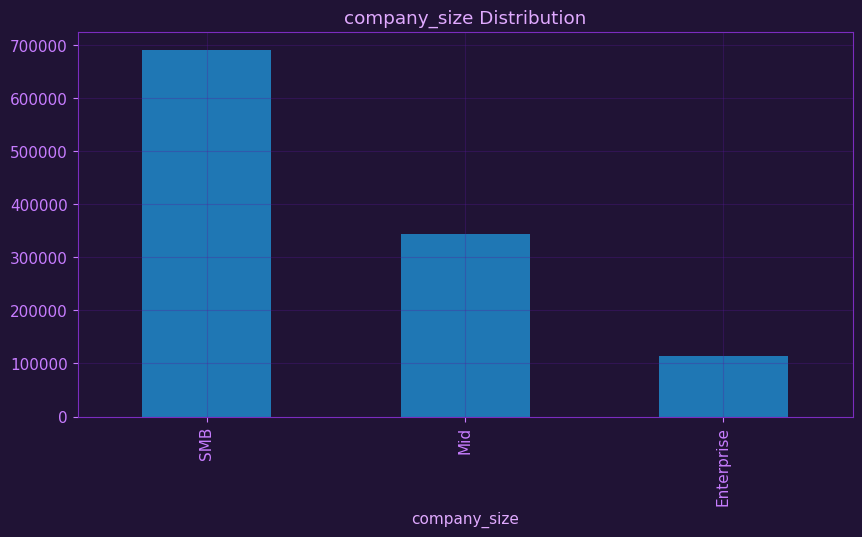


■ Insights
→ Check dominant categories.
! High imbalance may affect modeling.
════════════════════════════════════════════════════════════════════════════════
Industry Analysis
════════════════════════════════════════════════════════════════════════════════

■ Category Distribution
Consulting: 116679
SaaS: 115874
EdTech: 115598
Energy: 115253
Health: 115184
Logistics: 115092
Media: 114885
Fintech: 114563
Retail: 113597
Manufacturing: 113275


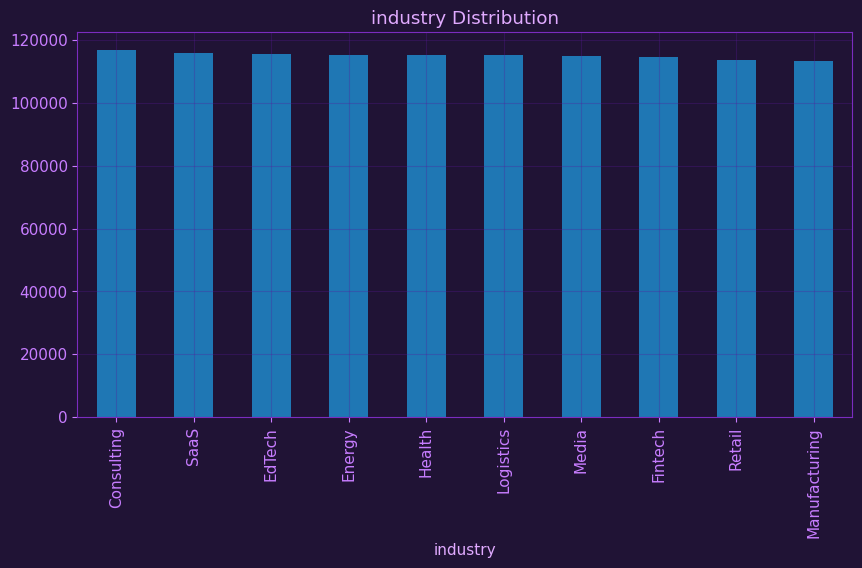


■ Insights
→ Check dominant categories.
! High imbalance may affect modeling.
════════════════════════════════════════════════════════════════════════════════
Contract Type Analysis
════════════════════════════════════════════════════════════════════════════════

■ Category Distribution
Monthly: 1064762
Annual: 85238


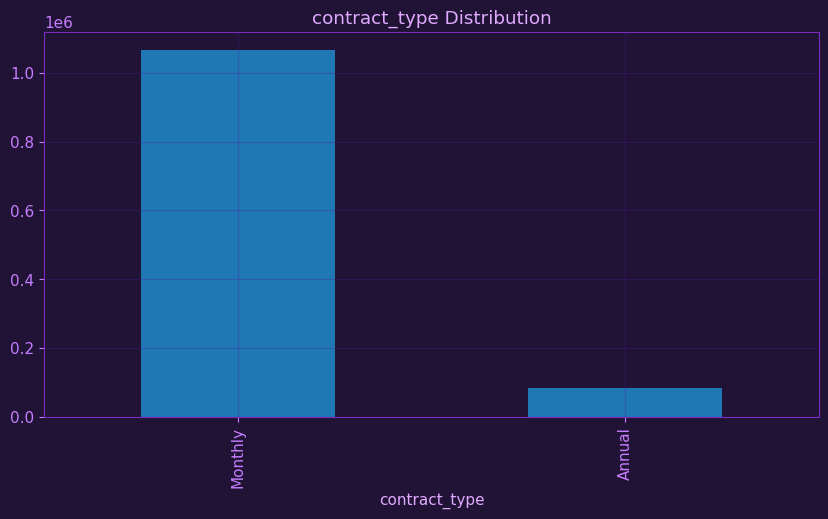


■ Insights
→ Check dominant categories.
! High imbalance may affect modeling.
════════════════════════════════════════════════════════════════════════════════
Regime State Analysis
════════════════════════════════════════════════════════════════════════════════

■ Category Distribution
stable: 506686
growth: 413980
decline: 229334


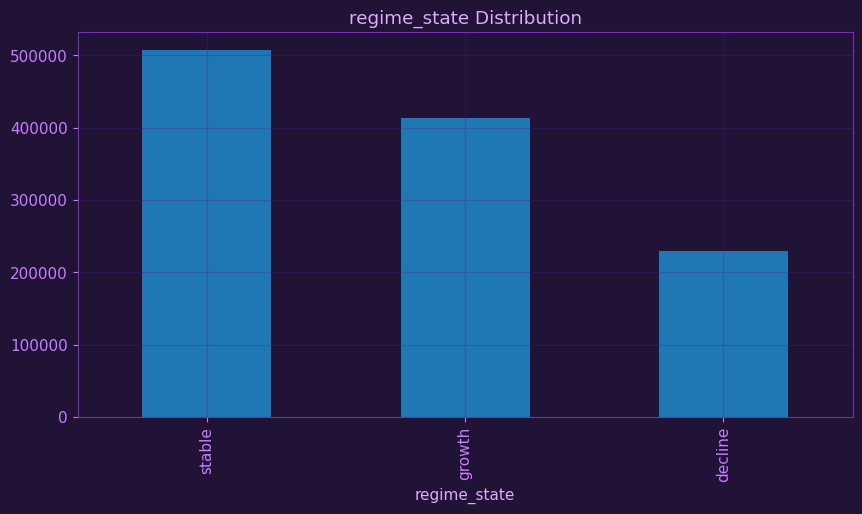


■ Insights
→ Check dominant categories.
! High imbalance may affect modeling.


In [23]:
analyze_categorical(df, "company_size", "Company Size Analysis")
analyze_categorical(df, "industry", "Industry Analysis")
analyze_categorical(df, "contract_type", "Contract Type Analysis")
analyze_categorical(df, "regime_state", "Regime State Analysis")

## 2.3 Behavior Analysis

════════════════════════════════════════════════════════════════════════════════
Active Users Analysis
════════════════════════════════════════════════════════════════════════════════

■ Basic Statistics
Mean: 89.22
Median: 70.0
Std: 76.13
Min: 1
Max: 990


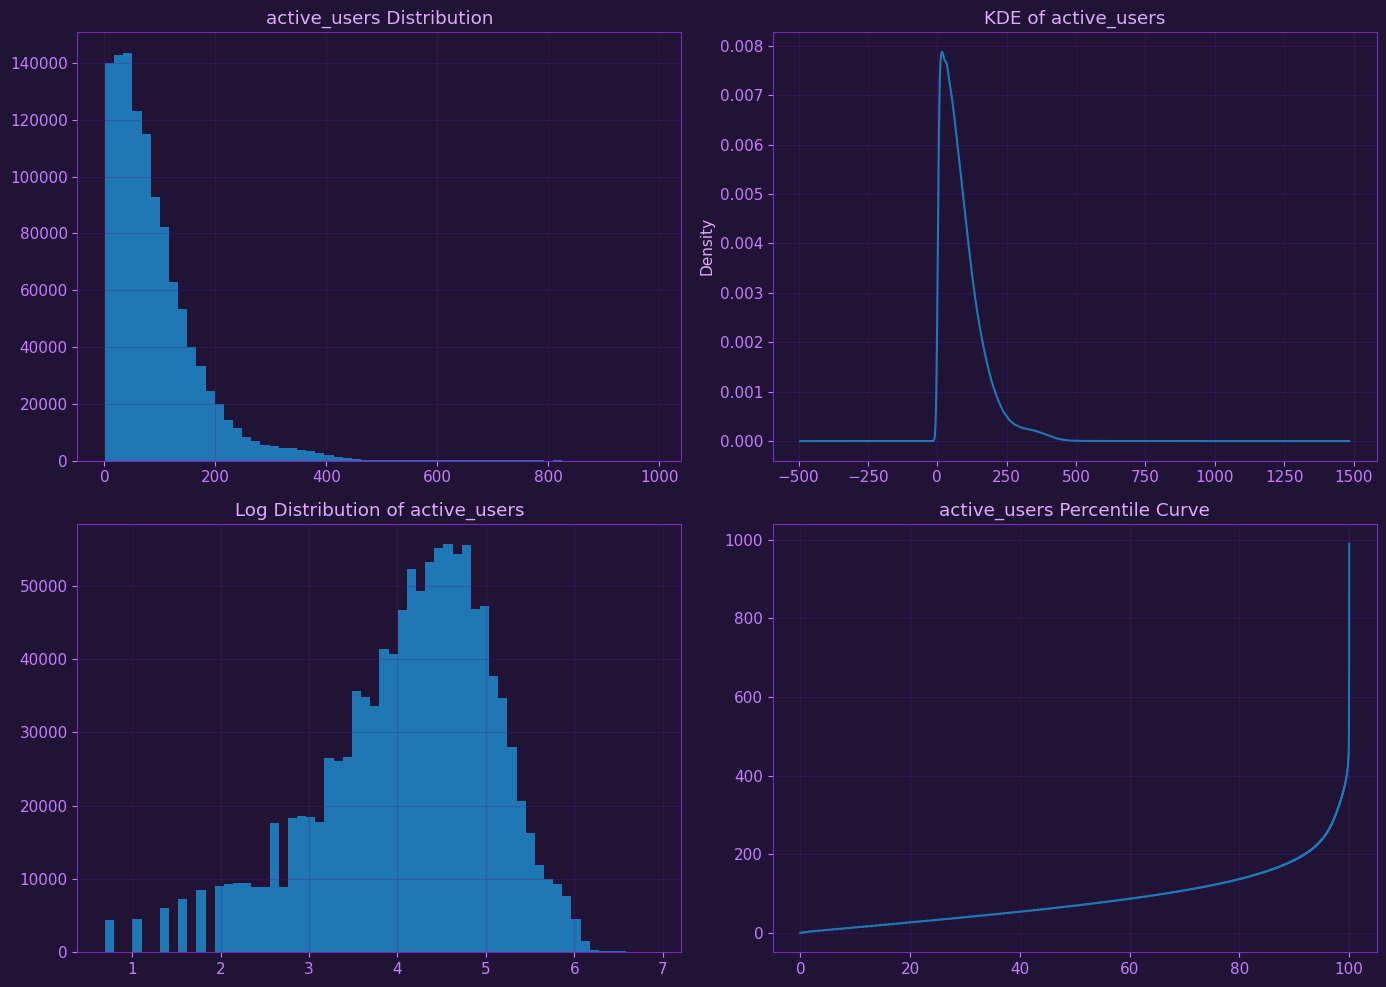


■ Insights
! Highly right-skewed distribution (long tail).
→ Check outliers in top percentiles.
→ Consider transformation for modeling if skewed.
════════════════════════════════════════════════════════════════════════════════
Usage Growth Analysis
════════════════════════════════════════════════════════════════════════════════

■ Basic Statistics
Mean: 0.01
Median: 0.01
Std: 0.04
Min: -0.15
Max: 0.17


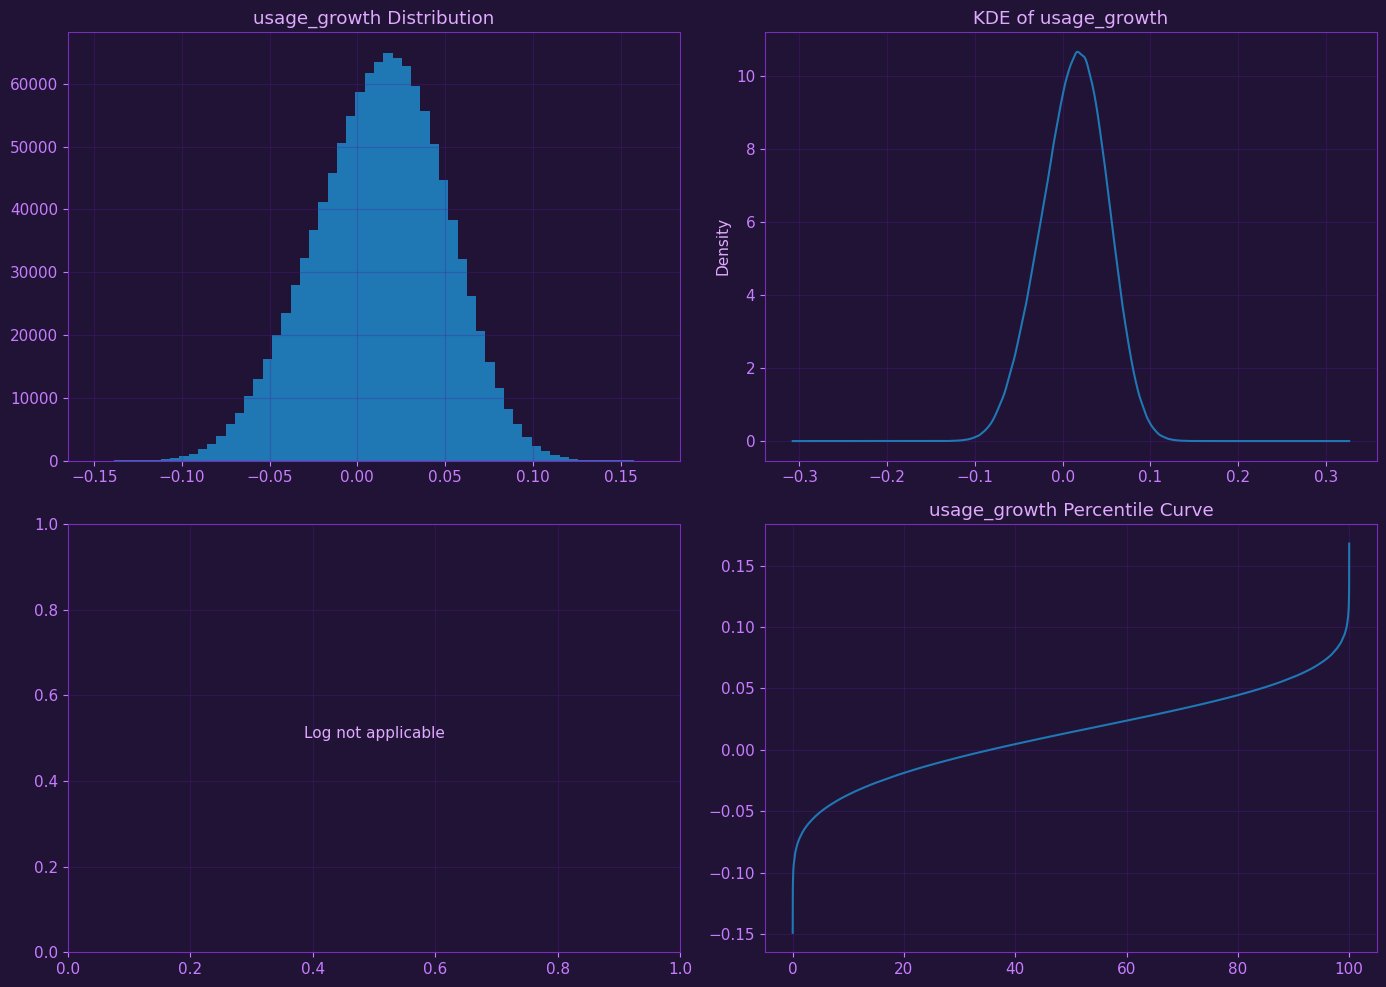


■ Insights
→ Approximately symmetric distribution.
→ Check outliers in top percentiles.
→ Consider transformation for modeling if skewed.
════════════════════════════════════════════════════════════════════════════════
Feature Adoption Analysis
════════════════════════════════════════════════════════════════════════════════

■ Basic Statistics
Mean: 0.49
Median: 0.47
Std: 0.35
Min: 0.0
Max: 1.0


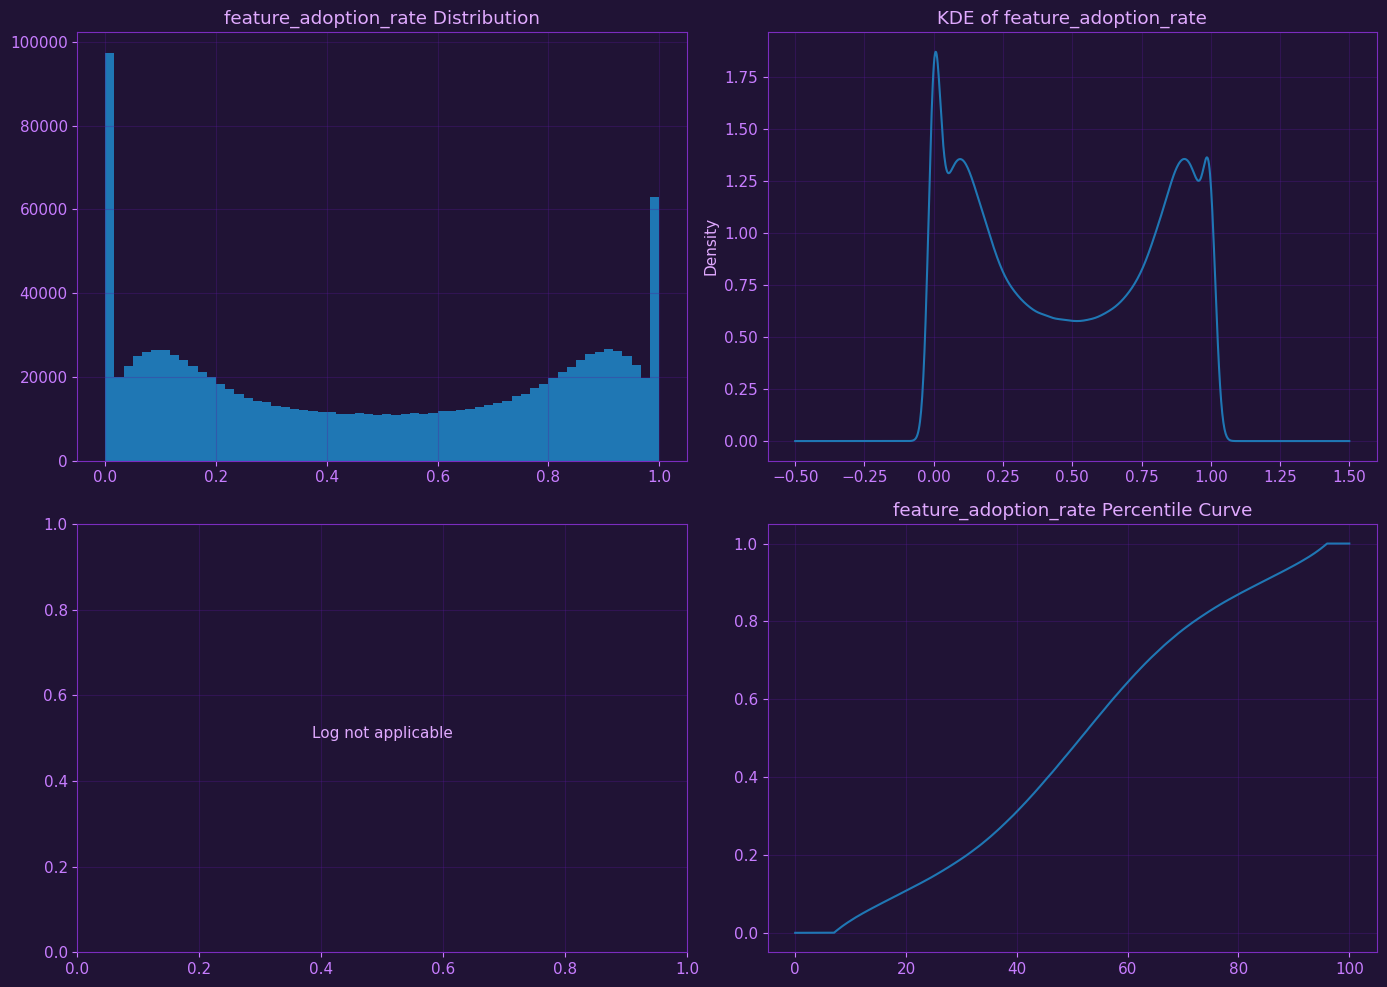


■ Insights
→ Approximately symmetric distribution.
→ Check outliers in top percentiles.
→ Consider transformation for modeling if skewed.


In [24]:
analyze_numeric_feature(df, "active_users", "Active Users Analysis")
analyze_numeric_feature(df, "usage_growth", "Usage Growth Analysis")
analyze_numeric_feature(df, "feature_adoption_rate", "Feature Adoption Analysis")

## 2.4 Issues Analysis

════════════════════════════════════════════════════════════════════════════════
Error Rate Analysis
════════════════════════════════════════════════════════════════════════════════

■ Basic Statistics
Mean: 0.1
Median: 0.09
Std: 0.07
Min: 0.0
Max: 0.65


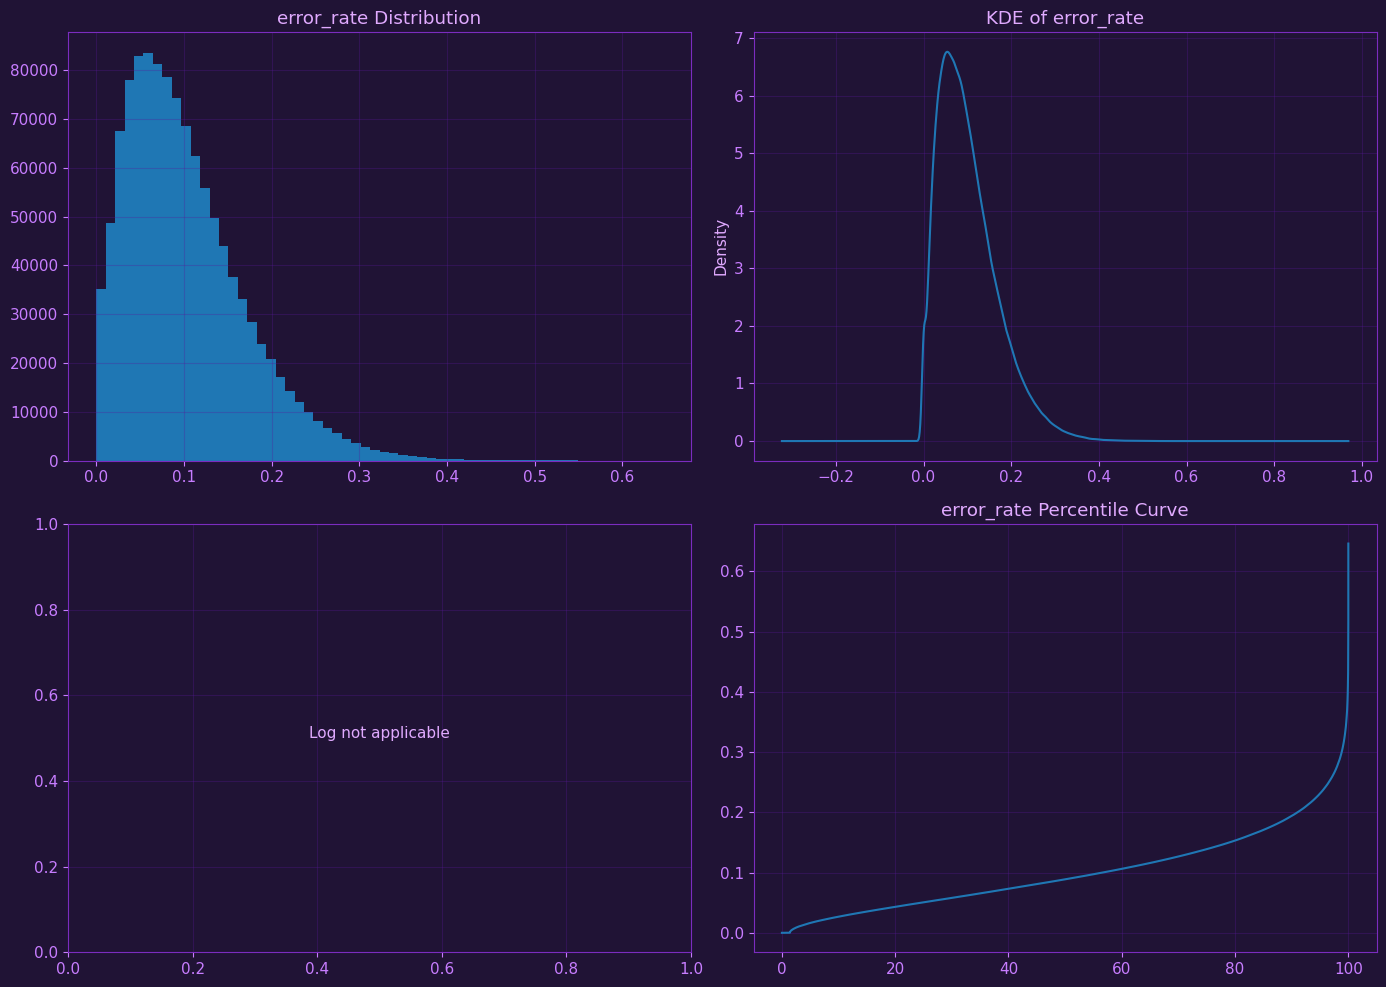


■ Insights
! Highly right-skewed distribution (long tail).
→ Check outliers in top percentiles.
→ Consider transformation for modeling if skewed.
════════════════════════════════════════════════════════════════════════════════
Tickets Count Analysis
════════════════════════════════════════════════════════════════════════════════

■ Basic Statistics
Mean: 4.8
Median: 4.0
Std: 4.22
Min: 0
Max: 43


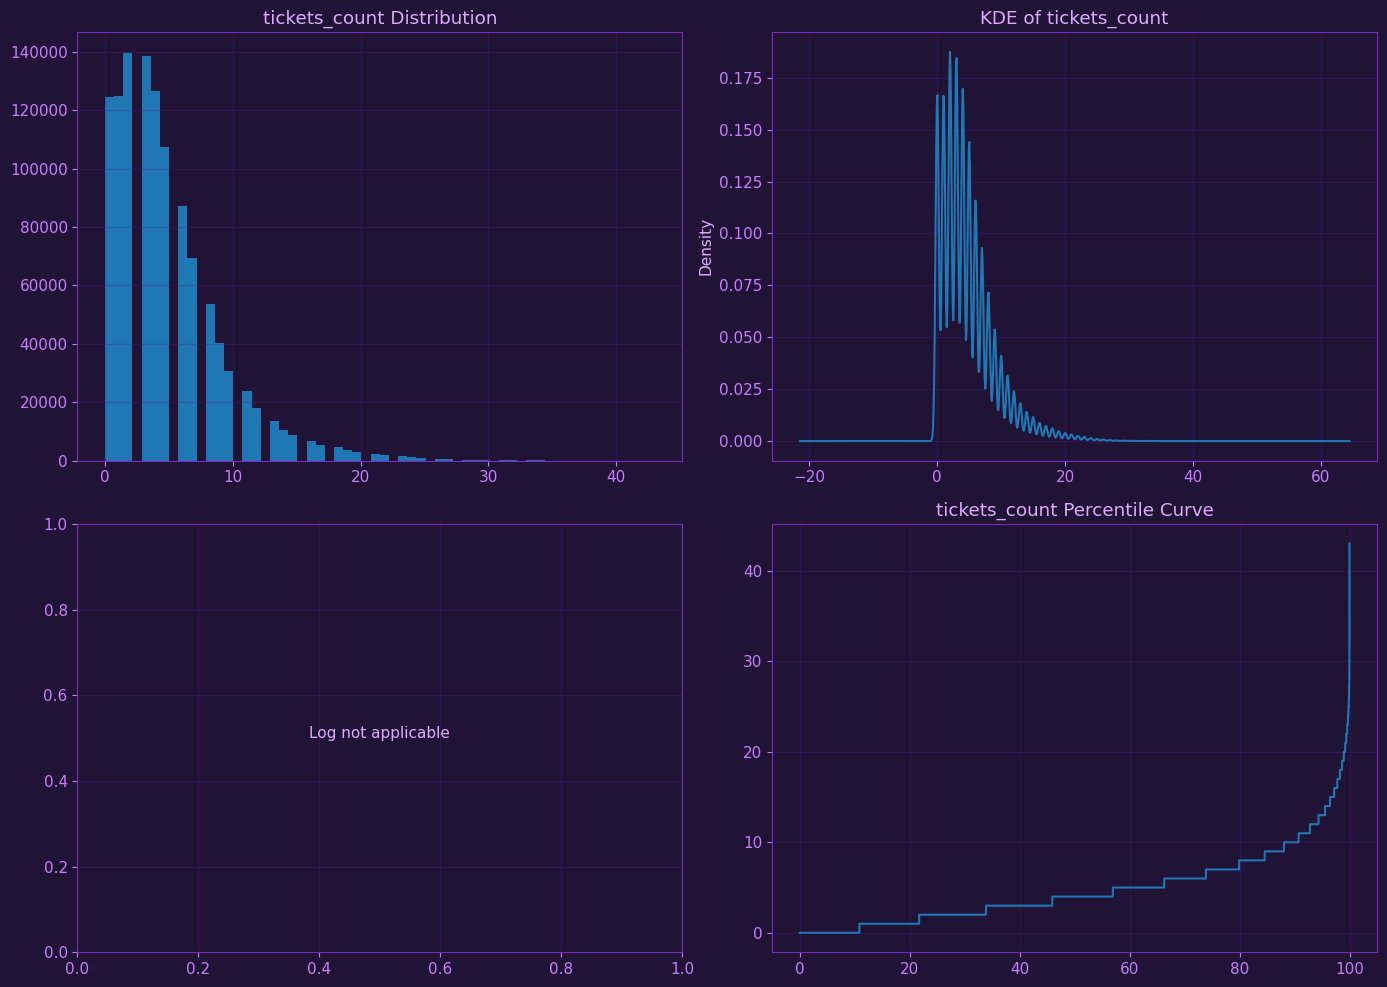


■ Insights
! Highly right-skewed distribution (long tail).
→ Check outliers in top percentiles.
→ Consider transformation for modeling if skewed.
════════════════════════════════════════════════════════════════════════════════
Ticket Growth Analysis
════════════════════════════════════════════════════════════════════════════════

■ Basic Statistics
Mean: 0.23
Median: 0.0
Std: 0.87
Min: -1.0
Max: 3.0


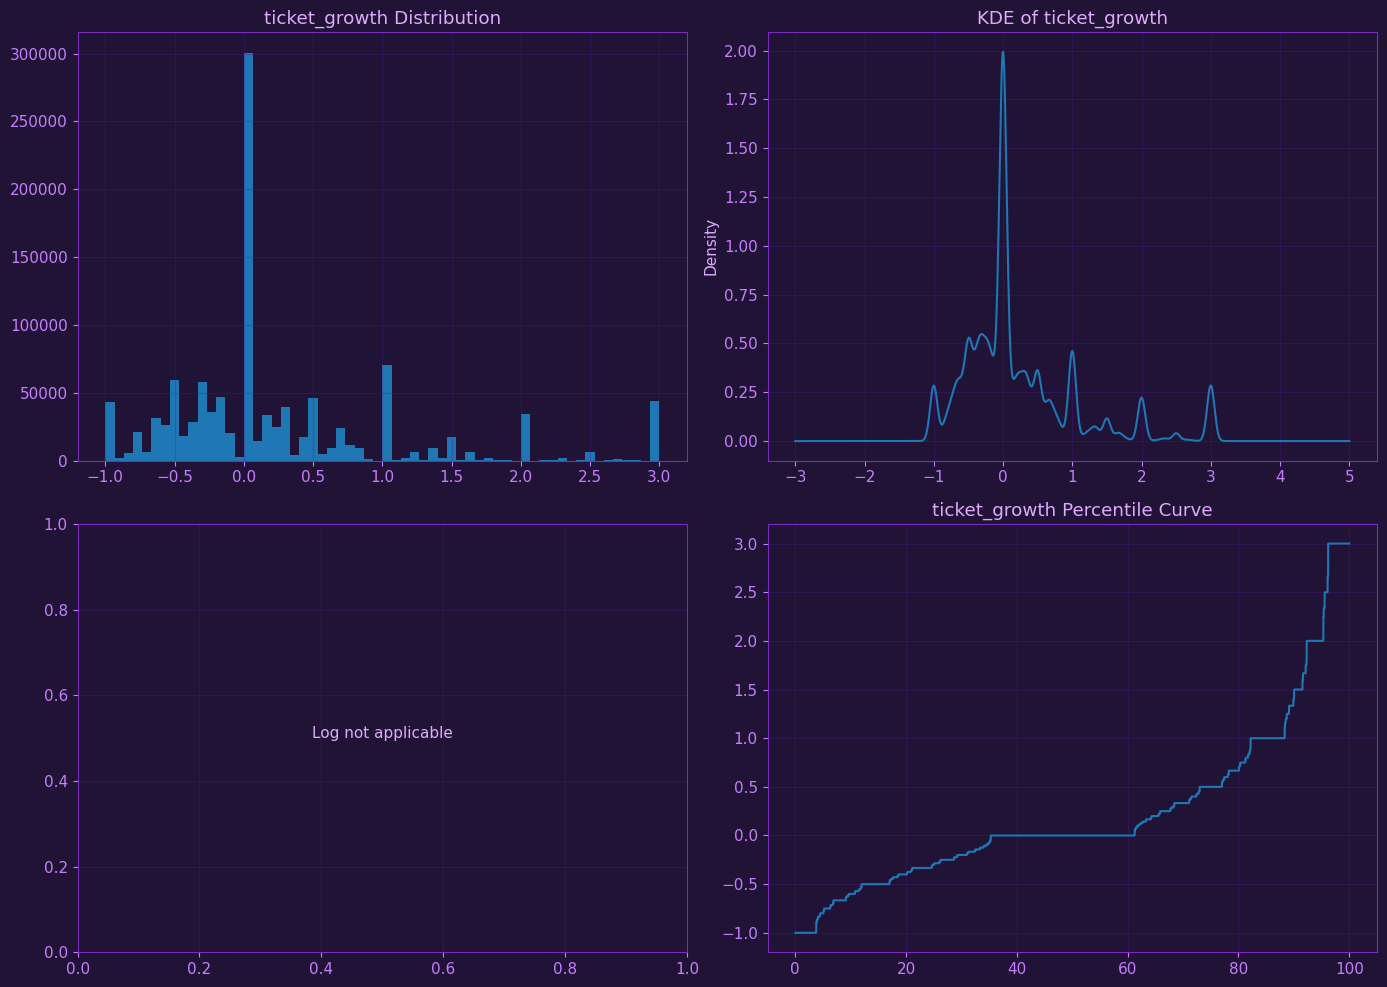


■ Insights
! Highly right-skewed distribution (long tail).
→ Check outliers in top percentiles.
→ Consider transformation for modeling if skewed.


In [25]:
analyze_numeric_feature(df, "error_rate", "Error Rate Analysis")
analyze_numeric_feature(df, "tickets_count", "Tickets Count Analysis")
analyze_numeric_feature(df, "ticket_growth", "Ticket Growth Analysis")

## 2.5 Revenue Analysis

════════════════════════════════════════════════════════════════════════════════
Discount Analysis
════════════════════════════════════════════════════════════════════════════════

■ Basic Statistics
Mean: 0.05
Median: 0.05
Std: 0.04
Min: 0.0
Max: 0.25


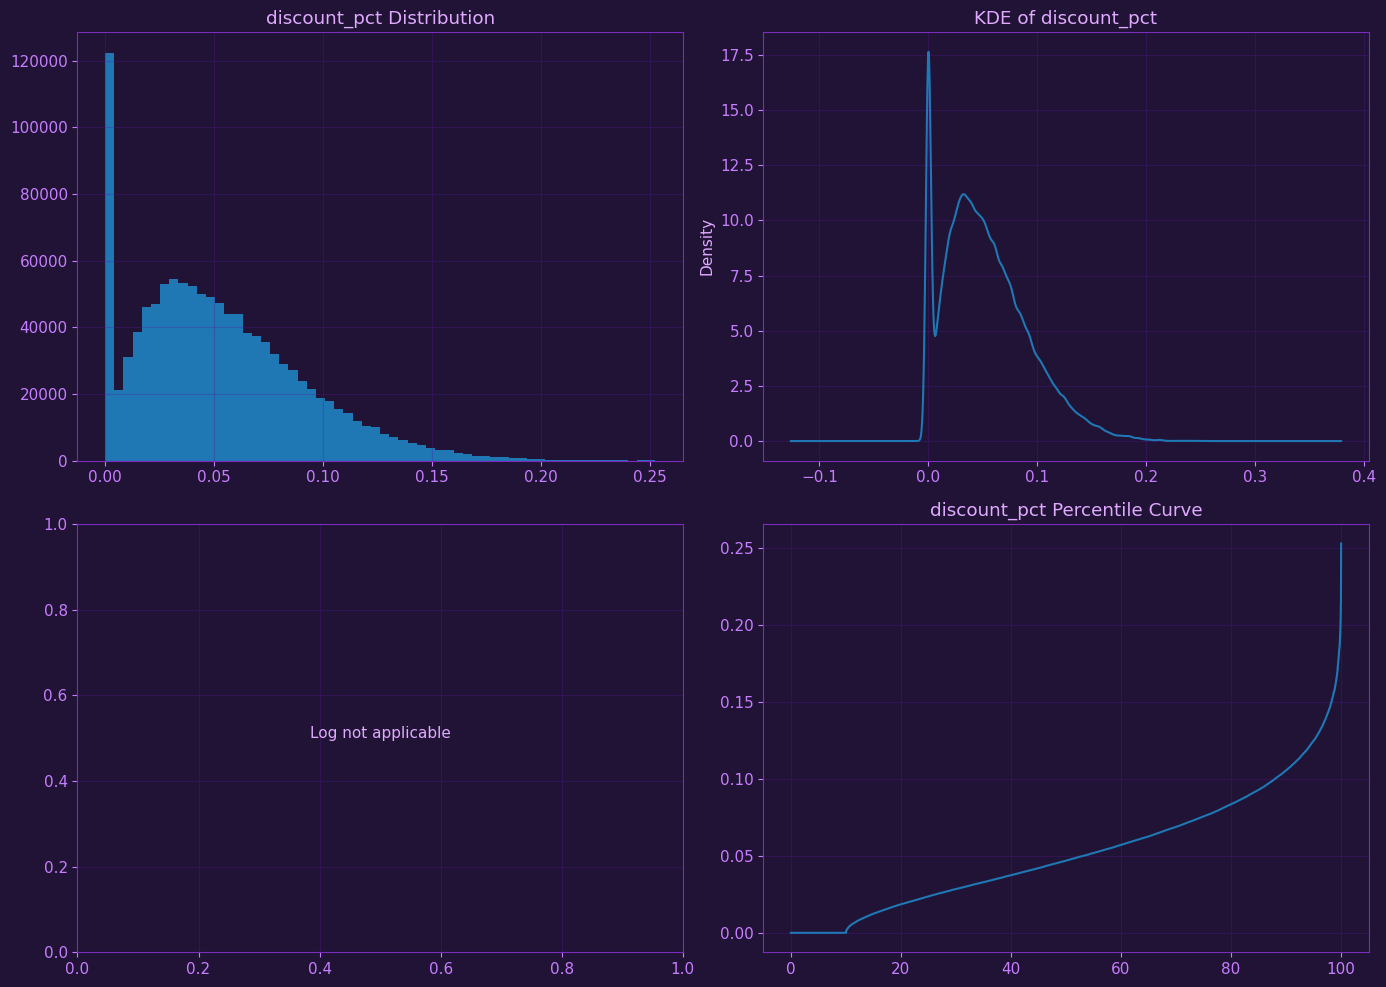


■ Insights
→ Approximately symmetric distribution.
→ Check outliers in top percentiles.
→ Consider transformation for modeling if skewed.
════════════════════════════════════════════════════════════════════════════════
Current MRR Analysis
════════════════════════════════════════════════════════════════════════════════

■ Basic Statistics
Mean: 321.8
Median: 69.14
Std: 1530.25
Min: 20.02
Max: 171608.97


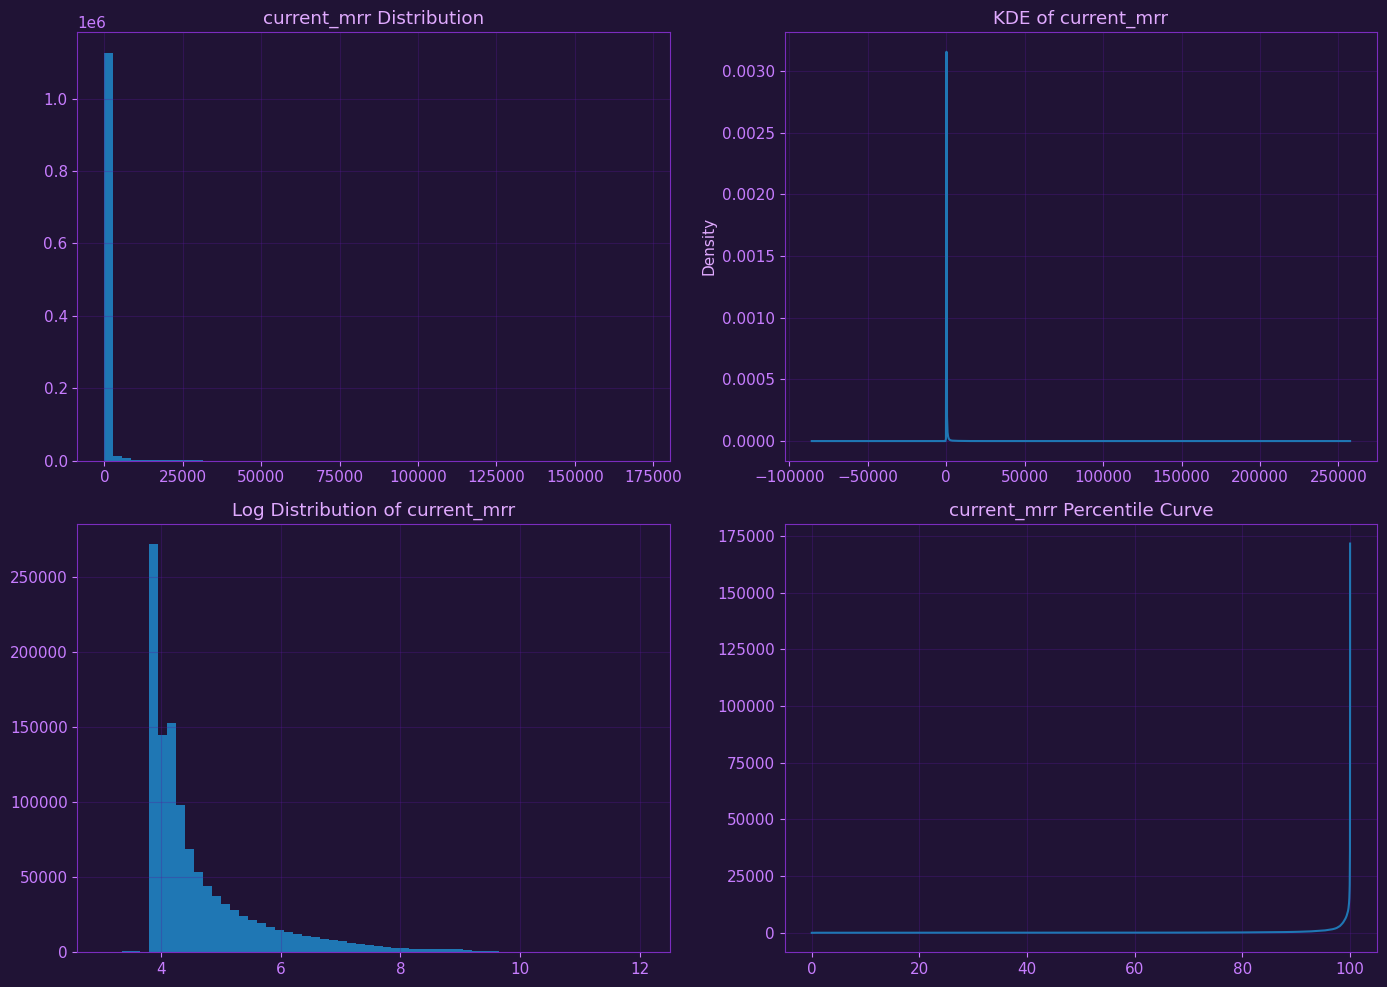


■ Insights
! Highly right-skewed distribution (long tail).
→ Check outliers in top percentiles.
→ Consider transformation for modeling if skewed.
════════════════════════════════════════════════════════════════════════════════
Next Month MRR Analysis
════════════════════════════════════════════════════════════════════════════════

■ Basic Statistics
Mean: 289.7
Median: 67.84
Std: 1597.27
Min: 50.0
Max: 269127.9


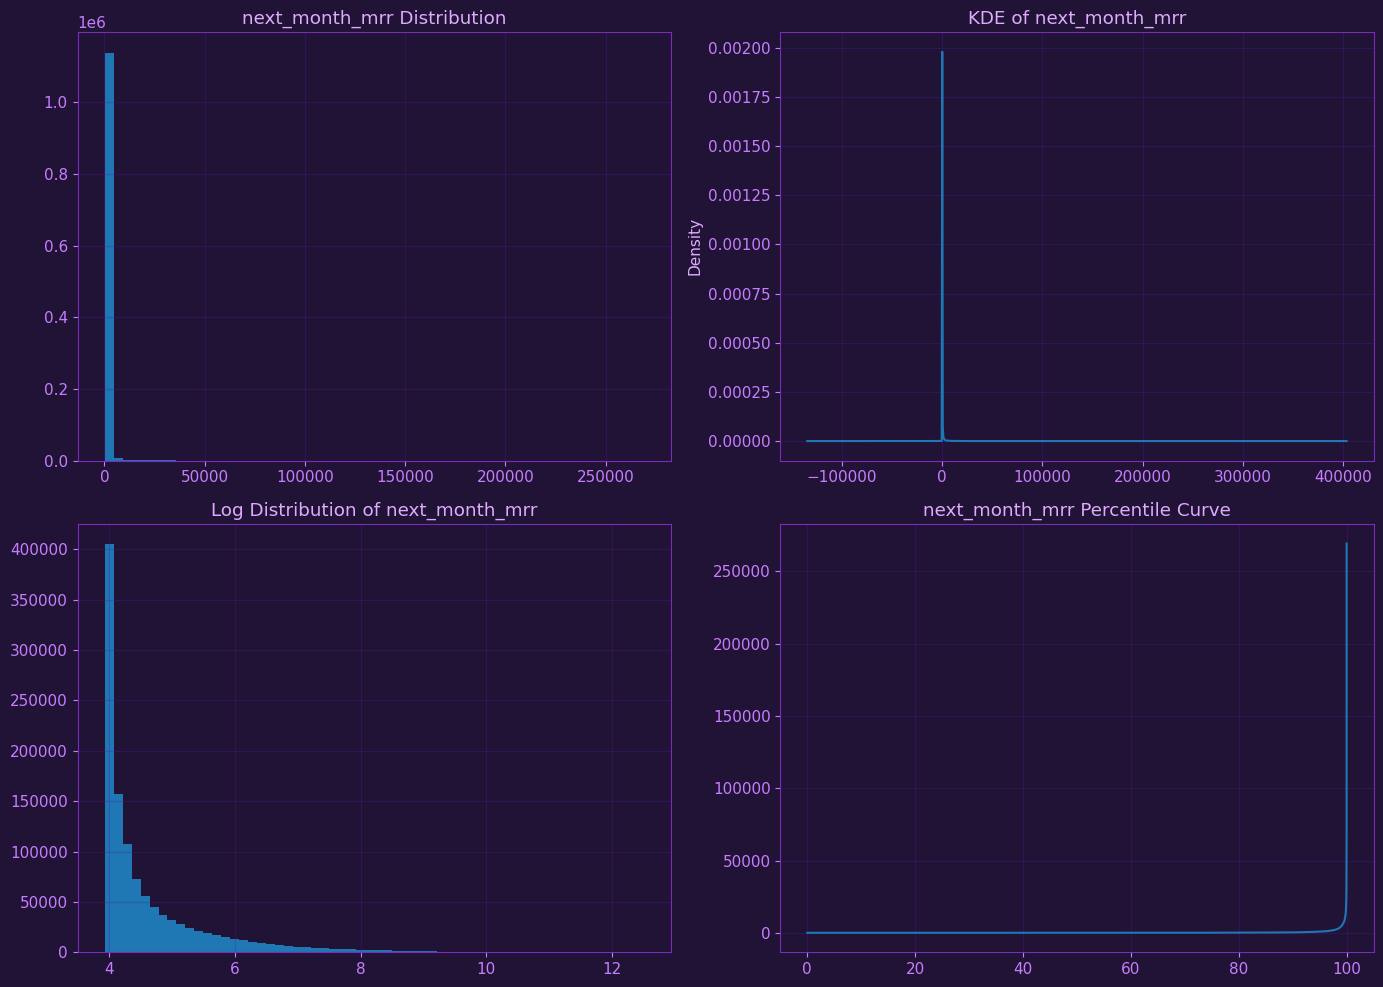


■ Insights
! Highly right-skewed distribution (long tail).
→ Check outliers in top percentiles.
→ Consider transformation for modeling if skewed.
════════════════════════════════════════════════════════════════════════════════
Payment Delay Analysis
════════════════════════════════════════════════════════════════════════════════
Delay Rate: 0.2719


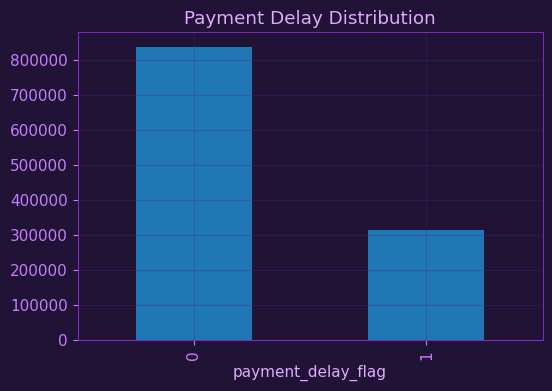

! Delayed payments indicate financial risk.


In [26]:
analyze_numeric_feature(df, "discount_pct", "Discount Analysis")
analyze_numeric_feature(df, "current_mrr", "Current MRR Analysis")
analyze_numeric_feature(df, "next_month_mrr", "Next Month MRR Analysis")

Printer.section("Payment Delay Analysis")
delay_rate = df["payment_delay_flag"].mean()
Printer.metric("Delay Rate", round(delay_rate, 4))

plt.figure(figsize=(6,4))
df["payment_delay_flag"].value_counts().plot(kind="bar")
plt.title("Payment Delay Distribution")
plt.grid(alpha=0.3)
plt.show()

Printer.warn("Delayed payments indicate financial risk.")

## 2.6 Heatmap (Correlation Matrix)

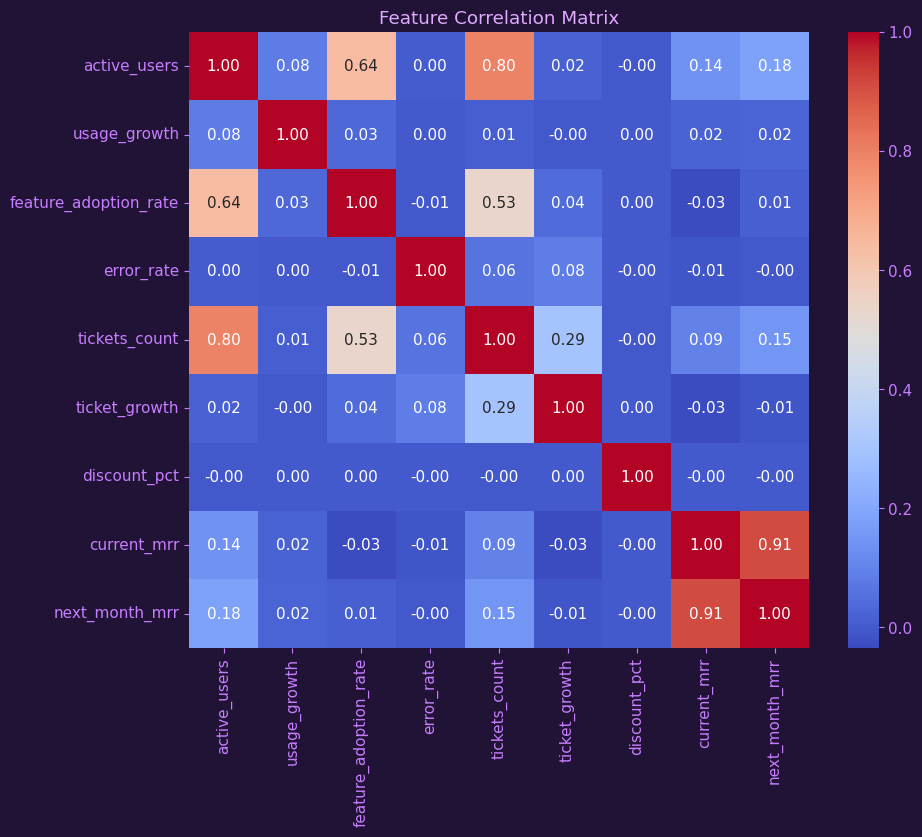


■ Correlation Insights
→ Current MRR strongly correlates with next month MRR.
→ Usage and adoption positively impact revenue.
! Error rate and ticket growth negatively affect performance.


In [33]:
plt.figure(figsize=(10,8))

corr = df[[
    "active_users","usage_growth","feature_adoption_rate",
    "error_rate","tickets_count","ticket_growth",
    "discount_pct","current_mrr","next_month_mrr"
]].corr()

sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()

Printer.subsection("Correlation Insights")
Printer.info("Current MRR strongly correlates with next month MRR.")
Printer.info("Usage and adoption positively impact revenue.")
Printer.warn("Error rate and ticket growth negatively affect performance.")

# 3. Final Anaylsis

## 3.1 Growth vs Revenue

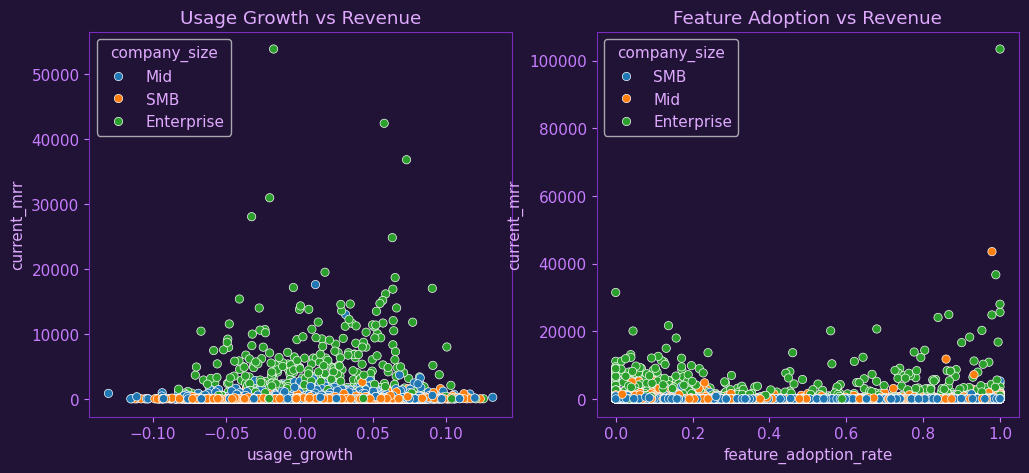


■ Product Engagement Impact
→ Higher usage growth correlates with higher revenue.
→ Feature adoption is a strong indicator of customer value.
! Low adoption accounts show weak revenue performance.


In [28]:
fig, ax = plt.subplots(1,2,figsize=(12,5))

sns.scatterplot(
    data=df.sample(10000),
    x="usage_growth",
    y="current_mrr",
    hue="company_size",
    ax=ax[0]
)
ax[0].set_title("Usage Growth vs Revenue")

sns.scatterplot(
    data=df.sample(10000),
    x="feature_adoption_rate",
    y="current_mrr",
    hue="company_size",
    ax=ax[1]
)
ax[1].set_title("Feature Adoption vs Revenue")

plt.show()

Printer.subsection("Product Engagement Impact")
Printer.info("Higher usage growth correlates with higher revenue.")
Printer.info("Feature adoption is a strong indicator of customer value.")
Printer.warn("Low adoption accounts show weak revenue performance.")

## 3.2 Usage Behavior

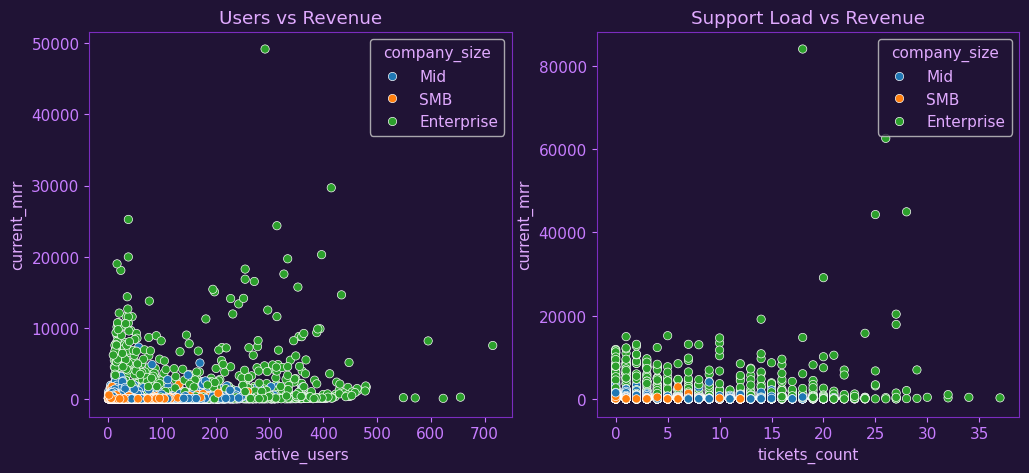


■ User Adoption Impact
→ Revenue generally increases with active users.
→ Enterprise accounts dominate the high-revenue segment.
! Some high-user accounts still produce low revenue.

■ Customer Support Pressure
→ Most accounts generate fewer than 10 support tickets.
→ Higher ticket volumes are mainly from Enterprise accounts.
! A few accounts create disproportionately high support load.


In [27]:
fig,ax = plt.subplots(1,2,figsize=(12,5))

sns.scatterplot(data=df.sample(10000),x="active_users",y="current_mrr",hue="company_size",ax=ax[0])
ax[0].set_title("Users vs Revenue")

sns.scatterplot(data=df.sample(10000),x="tickets_count",y="current_mrr",hue="company_size",ax=ax[1])
ax[1].set_title("Support Load vs Revenue")

plt.show()

Printer.subsection("User Adoption Impact")
Printer.info("Revenue generally increases with active users.")
Printer.info("Enterprise accounts dominate the high-revenue segment.")
Printer.warn("Some high-user accounts still produce low revenue.")


Printer.subsection("Customer Support Pressure")
Printer.info("Most accounts generate fewer than 10 support tickets.")
Printer.info("Higher ticket volumes are mainly from Enterprise accounts.")
Printer.warn("A few accounts create disproportionately high support load.")

## 3.3 Discount Effect on Revenue

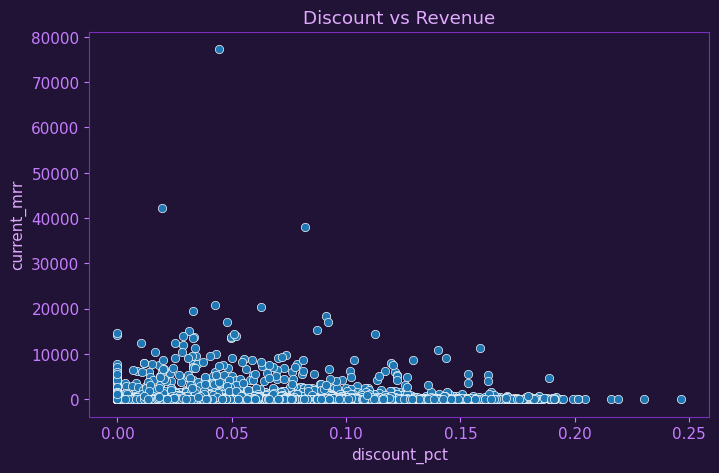


■ Discount Strategy
! Higher discounts do not always lead to higher revenue.
→ Some high-revenue accounts have low discounts.
! Over-discounting may reduce profitability.


In [30]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df.sample(10000),
    x="discount_pct",
    y="current_mrr"
)
plt.title("Discount vs Revenue")
plt.show()

Printer.subsection("Discount Strategy")
Printer.warn("Higher discounts do not always lead to higher revenue.")
Printer.info("Some high-revenue accounts have low discounts.")
Printer.warn("Over-discounting may reduce profitability.")

## 3.4 Company Size Distribution (Pie Chart)

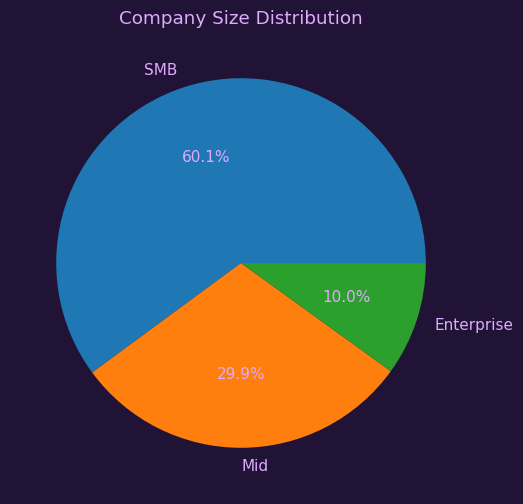


■ Customer Segmentation
→ Customer base is distributed across company sizes.
→ Enterprise share indicates strong high-value targeting.
! Over-reliance on one segment increases risk exposure.


In [ ]:
size_counts = df["company_size"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(size_counts, labels=size_counts.index, autopct="%1.1f%%")
plt.title("Company Size Distribution")
plt.show()

Printer.subsection("Customer Segmentation")
Printer.info("Customer base is distributed across company sizes.")
Printer.info("Enterprise share indicates strong high-value targeting.")
Printer.warn("Over-reliance on one segment increases risk exposure.")

## 3.5 Region Performance

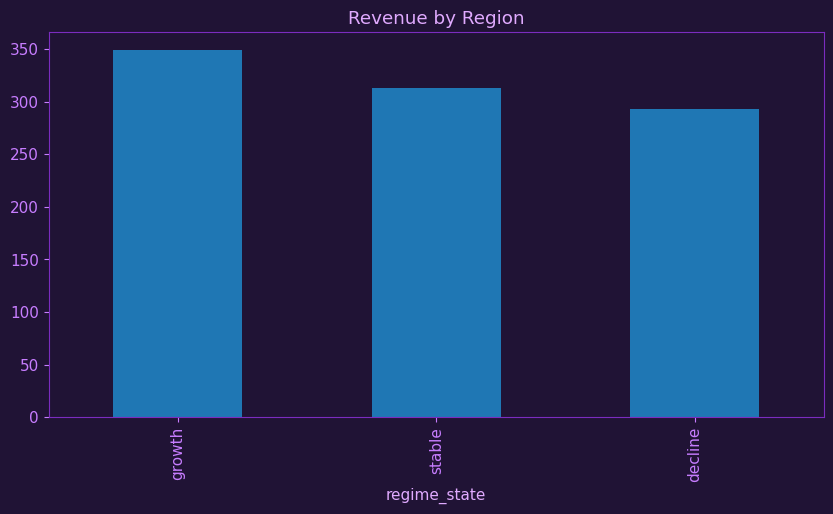


■ Geographic Insights
→ Some regions generate significantly higher revenue.
! Underperforming regions may need localization strategy.


In [41]:
region_rev = df.groupby("regime_state")["current_mrr"].mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))
region_rev.plot(kind="bar")
plt.title("Revenue by Region")
plt.show()
Printer.subsection("Geographic Insights")
Printer.info("Some regions generate significantly higher revenue.")
Printer.warn("Underperforming regions may need localization strategy.")

## 3.6 Monthly Growth Trend

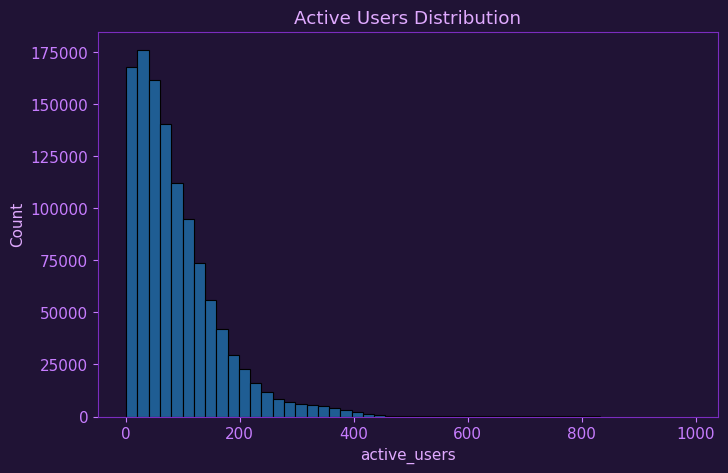


■ User Base Distribution
→ Most accounts have moderate user counts.
! Heavy-user accounts represent scaling opportunities.


In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df["active_users"], bins=50)
plt.title("Active Users Distribution")
plt.show()

Printer.subsection("User Base Distribution")
Printer.info("Most accounts have moderate user counts.")
Printer.warn("Heavy-user accounts represent scaling opportunities.")

## 3.7 Feature Adoption by Company Size

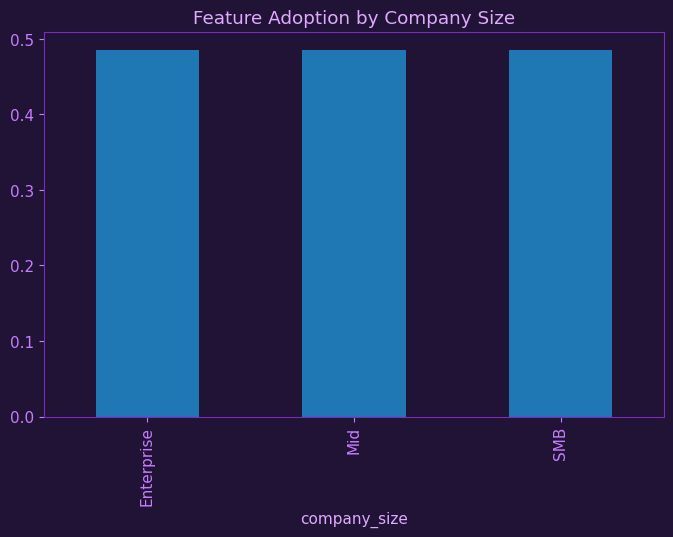


■ Adoption Behavior
→ Larger companies tend to adopt more features.
! Low adoption reduces product stickiness.


In [44]:
adoption = df.groupby("company_size")["feature_adoption_rate"].mean()

plt.figure(figsize=(8,5))
adoption.plot(kind="bar")
plt.title("Feature Adoption by Company Size")
plt.show()

Printer.subsection("Adoption Behavior")
Printer.info("Larger companies tend to adopt more features.")
Printer.warn("Low adoption reduces product stickiness.")

## 3.8 Payment Delay Ratio

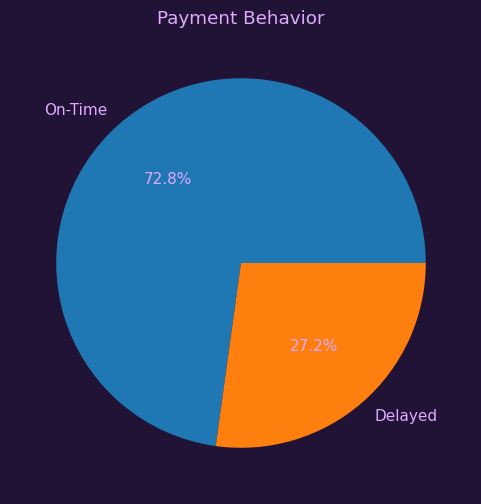


■ Payment Health
→ Most customers pay on time.
! Delayed payments signal financial or churn risk.


In [47]:
delay_counts = df["payment_delay_flag"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(delay_counts, labels=["On-Time","Delayed"], autopct="%1.1f%%")
plt.title("Payment Behavior")
plt.show()
Printer.subsection("Payment Health")
Printer.info("Most customers pay on time.")
Printer.warn("Delayed payments signal financial or churn risk.")

## 3.9 Current vs Next Month Revenue

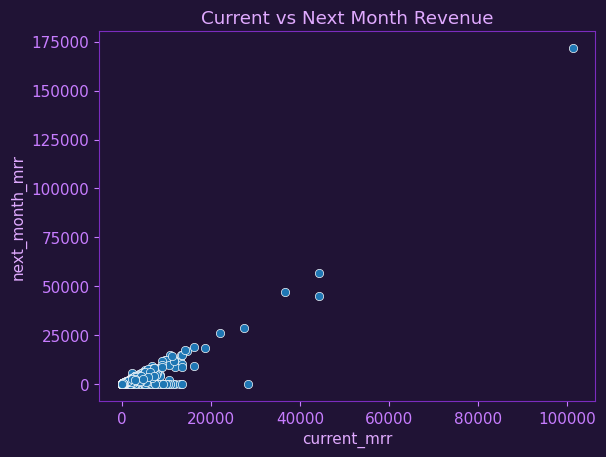


■ Revenue Predictability
→ Strong correlation indicates stable business.
! Outliers represent churn or expansion events.


In [49]:
sns.scatterplot(
    data=df.sample(10000),
    x="current_mrr",
    y="next_month_mrr"
)

plt.title("Current vs Next Month Revenue")
plt.show()
Printer.subsection("Revenue Predictability")
Printer.info("Strong correlation indicates stable business.")
Printer.warn("Outliers represent churn or expansion events.")